In [3]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import main_load_data

## Load source files

In [44]:
samples, cns = main_load_data()
datasets = list(samples["source"].unique())
datasets

['PCAWG', 'TRACERx', 'TCGA_hg19']

In [49]:
def get_table(subsample):
    total = len(subsample)
    table = []
    for i in range(0, subsample["breaks_aut"].max()):
        sample = subsample[subsample["breaks_aut"] >= i].shape[0]
        table.append([i, sample, sample / total * 100])

    table = pd.DataFrame(table, columns=["threshold", "samples", "percentage"])
    return table

Text(0.5, 0, 'Number of breaks')

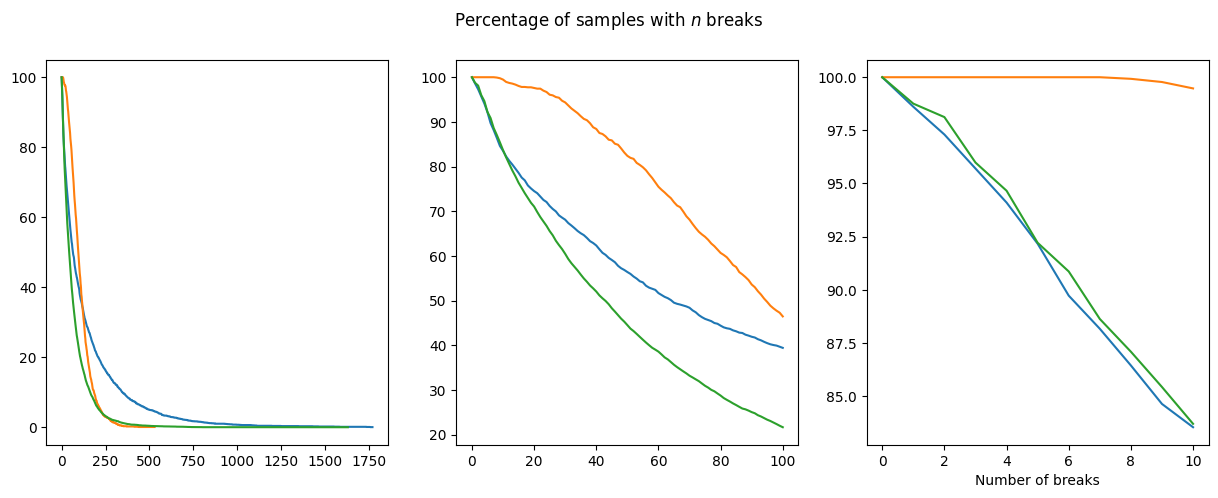

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Create a figure and a 1x3 subplot
for dataset in datasets:
    table = get_table(samples.query(f"source == '{dataset}'"))

    axs[0].plot(table["threshold"], table["percentage"])   

    selection = table[table["threshold"] <=100]  
    axs[1].plot(selection["threshold"], selection["percentage"])

    selection = table[table["threshold"] <=10]  
    axs[2].plot(selection["threshold"], selection["percentage"])

plt.suptitle("Percentage of samples with $n$ breaks")

In [61]:
from cns.utils.selection import cns_head
samp_cns = cns_head(cns, 1)

,sample_id,chrom,start,end,major_cn,minor_cn,length,mid,cum_mid,total_cn
0,CRUK0001_SU_T1-R1,chr1,0,22150118,2,2,22150118,11075059,11075059,4
1,CRUK0001_SU_T1-R1,chr1,22150118,22191498,3,3,41380,22170808,22170808,6
2,CRUK0001_SU_T1-R1,chr1,22191498,64100477,2,2,41908979,43145987,43145987,4
3,CRUK0001_SU_T1-R1,chr1,64100477,77333339,3,2,13232862,70716908,70716908,5
4,CRUK0001_SU_T1-R1,chr1,77333339,109369793,2,2,32036454,93351566,93351566,4
...,...,...,...,...,...,...,...,...,...,...
193,CRUK0001_SU_T1-R1,chr9,94456572,120671786,2,2,26215214,107564179,1646723891,4
194,CRUK0001_SU_T1-R1,chr9,120671786,138236121,4,1,17564335,129453953,1668613665,5
195,CRUK0001_SU_T1-R1,chr9,138236121,141213431,4,0,2977310,139724776,1678884488,4
196,CRUK0001_SU_T1-R1,chrX,0,155270560,0,0,155270560,77635280,2958668566,0
